# Analysis

## Imports

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.dpi'] = 200

## Load data

In [8]:
pretrain1_df = pd.read_parquet('../datasets/pretrain_part_1.parquet')
pretrain2_df = pd.read_parquet('../datasets/pretrain_part_2.parquet')
pretrain3_df = pd.read_parquet('../datasets/pretrain_part_3.parquet')

train1_df = pd.read_parquet('../datasets/train_part_1.parquet')
train2_df = pd.read_parquet('../datasets/train_part_2.parquet')
train3_df = pd.read_parquet('../datasets/train_part_3.parquet')

labels_df = pd.read_parquet('../datasets/train_labels.parquet')

## Preprocess

#### Проверим размеры датасетов:

In [4]:
print(f"train1_df: {train1_df.shape}")
print(f"labels_df: {labels_df.shape}")

train1_df: (28618594, 23)
labels_df: (87514, 3)


#### Проверим колонки датасетов и их типы данных:

In [5]:
print("train1_df:")
for col in train1_df.columns:
    print(f"- {col}: {train1_df[col].dtype}")

print("\nlabels_df:")
for col in labels_df.columns:
    print(f"- {col}: {labels_df[col].dtype}")

train1_df:
- customer_id: int64
- event_id: int64
- event_dttm: str
- event_type_nm: int32
- event_desc: int32
- channel_indicator_type: int32
- channel_indicator_sub_type: int32
- operaton_amt: float64
- currency_iso_cd: float64
- mcc_code: str
- pos_cd: float64
- accept_language: str
- browser_language: str
- timezone: float64
- session_id: float64
- operating_system_type: float64
- battery: str
- device_system_version: str
- screen_size: str
- developer_tools: str
- phone_voip_call_state: float64
- web_rdp_connection: float64
- compromised: str

labels_df:
- customer_id: int64
- event_id: int64
- target: int32


#### Добавляем в датасеты признаков разметку по классам:

In [9]:
train1_df = pd.merge(train1_df, labels_df, on=['customer_id', 'event_id'], how='left')
train2_df = pd.merge(train2_df, labels_df, on=['customer_id', 'event_id'], how='left')
train3_df = pd.merge(train3_df, labels_df, on=['customer_id', 'event_id'], how='left')

In [ ]:
print(train1_df['target'])

#### Заменяем пропущенные значения ("чистые" операции ранее имели NaN-значение):

In [ ]:
train1_df['target'] = train1_df['target'].fillna(-1)
print(train1_df['target'])

## Research 

#### Посмотрим, какое значение для анализа имеет каждый из признаков:

**Идентификационные данные**

`customer_id` - ID клиента  
`event_id` - ID операции  
`session_id` - ID сессии

Зачем: Позволяют выявлять аномальное поведение конкретного клиента или множественные операции в одной сессии

**Временные метки**

`event_dttm` - дата и время операции

Зачем: Фрод часто происходит в нерабочее время (ночью, в праздники)

**Типы операций**

`event_type_nm` - тип операции (например, покупка, перевод, снятие)  
`event_desc` - описание операции

Зачем: Некоторые типы операций более рискованны (например, крупные переводы)

**Каналы и устройства, с которых производится транзакция**

`channel_indicator_type` - тип канала (мобильное приложение, веб, терминал)  
`channel_indicator_sub_type` - подтип канала  
`operating_system_type` - ОС устройства  
`device_system_version` - версия ОС  
`screen_size` - размер экрана  
`battery` - уровень заряда батареи  
`phone_voip_call_state` - состояние VoIP звонка  
`browser_language` - язык браузера  
`accept_language` - Accept-Language заголовок  
`timezone` - часовой пояс  

Зачем:
* Несоответствие языка/часового пояса местоположению клиента
* Эмуляторы имеют специфические размеры экрана, уровень батареи (часто 100% или -1)
* VoIP состояние может указывать на подмену номера

**Финансовые данные**

`operaton_amt` - сумма операции  
`currency_iso_cd` - валюта

Зачем: Необычно крупные суммы, несоответствие валюты региону

**Геолокационные и торговые**

`mcc_code` - Merchant Category Code (код категории торговца)  
`pos_cd` - код точки продажи

Зачем: Подозрительные категории (казино, криптобиржи), несоответствие обычным паттернам покупок

**Технические признаки безопасности**

`developer_tools` - включены ли инструменты разработчика  
`web_rdp_connection` - подключение через RDP  
`compromised` - метка, что устройство/сессия скомпрометированы

Зачем:
* developer_tools = 1: попытка отладки/взлома
* web_rdp_connection = 1: удаленный доступ (частый признак мошенников)
* compromised = 1: уже известное скомпрометированное устройство

#### Проанализируем target:

Колонка `target` имеет значения 1, 0 и -1. Нам известно, что -1 - это самый часто встречающийся класс = "чистые" операции; два других означают подозрительные операции.

В задании указано, что **целевой класс, "красный свет" - это непотвержденные операции, класс 1.**  
Это означает, что когда банк зафиксировал подозрительную операцию, то связался с клиентом и задал вопрос "Это вы совершили операцию?" и клиент ответил "Нет, это не я".  
**Это и является фродом.**

Также имеется **"желтый свет"** - операции, подтвержденные клиентом - класс 0.  
Это означает, что когда банк зафиксировал подозрительную операцию, то клиент в ответ на вопрос банка подтвердил, что он сам совершил эту операцию.  
Это не целевой класс, не является фродом. Но он также может содержать выбросы по суммам или другие нетипичные значения в признаках.

Посмотрим "подозрительные" значения в обоих классах:

In [ ]:
for val in [0, 1]:
    subset = train1_df[train1_df['target'] == val]
    print(f"Класс {val} (n = {len(subset)})")
    
    rdp_pct = subset['web_rdp_connection'].mean() * 100
    print(f"RDP: {rdp_pct:.2f}%")
    
    if 'developer_tools' in subset.columns:
        dev_tools_numeric = pd.to_numeric(subset['developer_tools'], errors='coerce')
        dev_pct = dev_tools_numeric.mean() * 100
        print(f"Developer tools: {dev_pct:.2f}%")

    if 'compromised' in subset.columns:
        comp_numeric = pd.to_numeric(subset['compromised'], errors='coerce')
        comp_pct = comp_numeric.mean() * 100
        print(f"Compromised: {comp_pct:.2f}%")
    
    print(f"Средняя сумма: {subset['operaton_amt'].mean():.0f}")
    print(f"Медианная сумма: {subset['operaton_amt'].median():.0f}")
    print(f"Максимальная сумма: {subset['operaton_amt'].max():.0f}\n")

#### Значения для сабмита:

В примерах значений для сабмита есть числа типа -4, т.е. не вероятность (которая может быть только от 0 до 1).  

Это линейная комбинация весов признаков (буквально сумма значений признаков, умноженных на их веса, плюс сдвиг). Чем это значение меньше, тем ниже вероятность фрода, и наоборот.  
Это называется raw score (сырой скор), который легко конвертируется в вероятность и может быть получен в некоторых моделях напрямую вместо вероятности.

Например, в catboost:

`submission['predict'] = model.predict(X_test, prediction_type='RawFormulaVal')`

#### Распределение операций по времени суток:

In [ ]:
df_time = train1_df.copy()
df_time['event_dttm'] = pd.to_datetime(df_time['event_dttm'])
df_time['hour'] = df_time['event_dttm'].dt.hour
df_time['day_of_week'] = df_time['event_dttm'].dt.dayofweek
df_time['is_weekend'] = df_time['day_of_week'].isin([5, 6]).astype(int)
df_time['month'] = df_time['event_dttm'].dt.month
df_time['day_of_month'] = df_time['event_dttm'].dt.day

hourly_dist = {}
for val, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = df_time[df_time['target'] == val]
    hourly = subset['hour'].value_counts().sort_index()
    hourly_pct = (hourly / len(subset) * 100).round(2)
    hourly_dist[name] = hourly_pct
    
    print(f"{name}, n = {len(subset)}):")
    
    day_pct = (subset['hour'].between(8, 20)).mean() * 100
    night_pct = (subset['hour'].between(0, 5)).mean() * 100
    morning_pct = (subset['hour'].between(6, 7)).mean() * 100
    evening_pct = (subset['hour'].between(21, 23)).mean() * 100
    
    print(f"  День (8-18): {day_pct:.1f}%")
    print(f"  Вечер (19-23): {evening_pct:.1f}%")
    print(f"  Ночь (0-4): {night_pct:.1f}%")
    print(f"  Утро (5-7): {morning_pct:.1f}%\n")
    
fraud = df_time[df_time['target'] == 1]
fraud_hourly = fraud['hour'].value_counts().sort_index()
fraud_hourly_pct = fraud_hourly / len(fraud) * 100

plt.figure(figsize=(12, 6))

for val, name, color in [(-1, 'Чистые', 'green'), (0, 'Подозр. подтв.', 'orange'), (1, 'Фрод', 'red')]:
    subset = df_time[df_time['target'] == val]
    hourly = subset['hour'].value_counts().sort_index()
    hourly_pct = hourly / len(subset) * 100
    plt.plot(hourly_pct.index, hourly_pct.values, marker='o', label=name, color=color)

plt.xlabel('Час дня')
plt.ylabel('Процент операций')
plt.title('Распределение операций по часам')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(24))
plt.show()

Видим, что нет четкой зависимости вида операций от времени суток (фрод НЕ совершается чаще ночью и т.п.)

#### Распределение операций по дням недели:

In [ ]:
russian_holidays = [
    (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7),
    (2, 23),
    (3, 8),
    (5, 1), (5, 9),
    (6, 12),
    (11, 4),
]

df_time['is_holiday'] = df_time.apply(
    lambda row: (row['month'], row['day_of_month']) in russian_holidays, 
    axis=1
).astype(int)

print("Операции в выходные:")
for val, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = df_time[df_time['target'] == val]
    weekend_pct = subset['is_weekend'].mean() * 100
    print(f"  {name}: {weekend_pct:.1f}%")

print("\nОперации в праздники:")
for val, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = df_time[df_time['target'] == val]
    holiday_pct = subset['is_holiday'].mean() * 100
    print(f"  {name}: {holiday_pct:.1f}%")

plt.figure(figsize=(10, 6))

days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
for val, name, color in [(-1, 'Чистые', 'green'), (0, 'Подозр. подтв.', 'orange'), (1, 'Фрод', 'red')]:
    subset = df_time[df_time['target'] == val]
    dow_dist = subset['day_of_week'].value_counts().sort_index()
    dow_pct = (dow_dist / len(subset) * 100).reindex(range(7), fill_value=0)
    plt.plot(days, dow_pct.values, marker='o', label=name, color=color, linewidth=2)

plt.xlabel('День недели')
plt.ylabel('Процент операций')
plt.title('Распределение операций по дням недели')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))

months = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
          'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
for val, name, color in [(-1, 'Чистые', 'green'), (0, 'Подозр. подтв.', 'orange'), (1, 'Фрод', 'red')]:
    subset = df_time[df_time['target'] == val]
    month_dist = subset['month'].value_counts().sort_index()
    month_pct = (month_dist / len(subset) * 100).reindex(range(1, 13), fill_value=0)
    plt.plot(months, month_pct.values, marker='o', label=name, color=color, linewidth=2)

plt.xlabel('Месяц')
plt.ylabel('Процент операций')
plt.title('Распределение операций по месяцам')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Распределение операций по часовым поясам:

In [ ]:
df_geo = train1_df.copy()

for val, name in [(-1, 'Чистые'), (0, 'Подозр./подтв.'), (1, 'Фрод')]:
    subset = df_geo[df_geo['target'] == val]
    print(f"\n{name} (n={len(subset)}):")
    
    top_tz = subset['timezone'].value_counts().head(5)
    top_tz_pct = subset['timezone'].value_counts(normalize=True).head(5) * 100
    
    for tz, count in top_tz.items():
        pct = top_tz_pct[tz]
        print(f"  TZ {tz:.0f}: {count} оп. ({pct:.1f}%)")

plt.figure(figsize=(14, 6))

top15_tz = df_geo['timezone'].value_counts().head(15).sort_index()

for val, name, color in [(-1, 'Чистые', 'green'), (0, 'Подозр./подтв.', 'orange'), (1, 'Фрод', 'red')]:
    subset = df_geo[df_geo['target'] == val]

    tz_dist = subset['timezone'].value_counts()
    tz_dist_pct = (tz_dist / len(subset) * 100)
    tz_dist_pct = tz_dist_pct.reindex(top15_tz.index, fill_value=0)
    
    plt.plot(tz_dist_pct.index, tz_dist_pct.values, marker='o', label=name, color=color, linewidth=2)

plt.xlabel('Часовой пояс')
plt.ylabel('Процент операций')
plt.title('Распределение операций по часовым поясам (топ-15)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Анализ существующих признаков для предобработки:

#### battery

In [ ]:
battery_vals = train1_df['battery'].unique()
print(f"Всего уникальных значений батареи: {len(battery_vals)}")

for i, val in enumerate(battery_vals):
    val_str = str(val)[:100]
    print(f"{val_str}")

Видим, что в колонке батареи есть как разные проценты, так и NaN-значения, и non available, и мусорные значения. Посмотрим их распределение.

In [ ]:
df_plot = train1_df.copy()

def get_battery_category(val):
    if pd.isna(val) or val == 'NaN%':
        return 'NaN (пропуски)'
    elif val == 'not available':
        return 'not available'
    elif isinstance(val, str) and val.endswith('%'):
        return 'Проценты'
    else:
        return 'Мусор (длинные строки)'

df_plot['battery_cat'] = df_plot['battery'].apply(get_battery_category)

total_dist = df_plot['battery_cat'].value_counts()
total_pct = df_plot['battery_cat'].value_counts(normalize=True) * 100

for cat in ['Проценты', 'not available', 'NaN (пропуски)', 'Мусор (длинные строки)']:
    if cat in total_dist.index:
        print(f"  {cat}: {total_dist[cat]} ({total_pct[cat]:.10f}%)")
    else:
        print(f"  {cat}: 0 (0.0000000000%)")

class_dist = {}

for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = df_plot[df_plot['target'] == target]
    dist = subset['battery_cat'].value_counts(normalize=True) * 100
    class_dist[name] = dist
    print(f"\n{name} (n = {len(subset)}):")
    for cat in ['Проценты', 'not available', 'NaN (пропуски)', 'Мусор (длинные строки)']:
        if cat in dist.index:
            print(f"  {cat}: {dist[cat]:.2f}%")
        else:
            print(f"  {cat}: 0.0000000000%")

fig, ax = plt.subplots(figsize=(12, 6))

categories = ['Проценты', 'not available', 'NaN (пропуски)', 'Мусор (длинные строки)']
x = np.arange(len(categories))
width = 0.25

values = []
for name in ['Чистые', 'Подозр. подтв.', 'Фрод']:
    values.append([class_dist[name].get(cat, 0) for cat in categories])

bars1 = ax.bar(x - width, values[0], width, label='Чистые', color='green', alpha=0.7)
bars2 = ax.bar(x, values[1], width, label='Подозр. подтв.', color='orange', alpha=0.7)
bars3 = ax.bar(x + width, values[2], width, label='Фрод', color='red', alpha=0.7)

ax.set_xlabel('Категория батареи')
ax.set_ylabel('Процент от класса')
ax.set_title('Распределение состояний батареи по классам')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 1:
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                   f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

Создадим 3 бинарных признака: имеется/не имеется заряд; батарея недоступна; мусор. Четвертое значение (NaN) будет отсутствием значений во всех признаках.  
Примерно так:

In [ ]:
"""
df['battery_percent'] = (df['battery'].astype(str).str.endswith('%') & (df['battery'] != 'NaN%')).astype(int)
df['battery_not_available'] = (df['battery'] == 'not available').astype(int)
df['battery_garbage'] = (~df['battery'].isna() & 
                         ~df['battery'].astype(str).str.endswith('%') & 
                         (df['battery'] != 'not available') & 
                         (df['battery'] != 'NaN%')).astype(int)
"""

#### event_type_nm

In [ ]:
print(f"Тип данных: {train1_df['event_type_nm'].dtype}")
print(f"Уникальных значений: {train1_df['event_type_nm'].nunique()}")
print(f"Пропусков: {train1_df['event_type_nm'].isna().sum()}\n")
print(train1_df['event_type_nm'].value_counts())

print("\nРаспределение топ-5 типов по классам:")
top5 = train1_df['event_type_nm'].value_counts().head(5).index

for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = train1_df[train1_df['target'] == target]
    print(f"\n{name}:")
    type_dist = subset['event_type_nm'].value_counts(normalize=True).head(5) * 100
    for type_val, pct in type_dist.items():
        if type_val in top5:
            print(f"  Тип {type_val}: {pct:.2f}%")

#### event_desc

In [ ]:
print(f"Тип данных: {train1_df['event_desc'].dtype}")
print(f"Уникальных значений: {train1_df['event_desc'].nunique()}")
print(f"Пропусков: {train1_df['event_desc'].isna().sum()}")

print("\nТоп-20 самых частых значений:")
print(train1_df['event_desc'].value_counts())

# 3. Статистика по классам
print("\nРаспределение топ-5 значений по классам:")
top5_desc = train1_df['event_desc'].value_counts().head(5).index

for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = train1_df[train1_df['target'] == target]
    print(f"\n{name}:")
    desc_dist = subset['event_desc'].value_counts(normalize=True).head(5) * 100
    for desc_val, pct in desc_dist.items():
        if desc_val in top5_desc:
            print(f"  {desc_val}: {pct:.2f}%")

print("\nСвязь с event_type_nm:")
desc_type_corr = train1_df.groupby(['event_desc', 'event_type_nm']).size().reset_index(name='count')
desc_type_corr = desc_type_corr.sort_values('count', ascending=False).head(10)
print(desc_type_corr)

#### channel_indicator_type

In [ ]:
print(f"Тип данных: {train1_df['channel_indicator_type'].dtype}")
print(f"Уникальных значений: {train1_df['channel_indicator_type'].nunique()}")
print(f"Пропусков: {train1_df['channel_indicator_type'].isna().sum()}")

# 2. Распределение значений
print("\nРаспределение значений:")
print(train1_df['channel_indicator_type'].value_counts().head(10))

# 3. Распределение по классам
print("\nРаспределение топ-5 значений по классам:")
top5 = train1_df['channel_indicator_type'].value_counts().head(5).index

for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = train1_df[train1_df['target'] == target]
    print(f"\n{name}:")
    dist = subset['channel_indicator_type'].value_counts(normalize=True).head(5) * 100
    for val, pct in dist.items():
        if val in top5:
            print(f"  Тип {val}: {pct:.2f}%")

#### channel_indicator_sub_type

In [ ]:
print(f"Тип данных: {train1_df['channel_indicator_sub_type'].dtype}")
print(f"Уникальных значений: {train1_df['channel_indicator_sub_type'].nunique()}")
print(f"Пропусков: {train1_df['channel_indicator_sub_type'].isna().sum()}")

print("\nРаспределение значений:")
print(train1_df['channel_indicator_sub_type'].value_counts())

#### operaton_amt

In [ ]:
print(f"Тип данных: {train1_df['operaton_amt'].dtype}")
print(f"Пропусков: {train1_df['operaton_amt'].isna().sum()}")

print("\nСтатистика по классам:")
for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = train1_df[train1_df['target'] == target]['operaton_amt']
    print(f"\n{name}:")
    print(f"  Среднее: {subset.mean():.2f}")
    print(f"  Медиана: {subset.median():.2f}")
    print(f"  Мин: {subset.min():.2f}")
    print(f"  Макс: {subset.max():.2f}")
    print(f"  25%: {subset.quantile(0.25):.2f}")
    print(f"  75%: {subset.quantile(0.75):.2f}")
    print(f"  95%: {subset.quantile(0.95):.2f}")
    print(f"  99%: {subset.quantile(0.99):.2f}")

Видим, что в данных почти половина пропусков. Можно создать бинарный признак "сумма отсутствует". Сначала проверим, есть ли зависимость фрода и отсутствия суммы.

In [ ]:
df_check = train1_df.copy()
df_check['amount_missing'] = df_check['operaton_amt'].isna().astype(int)

total_missing = df_check['amount_missing'].sum()
total_ops = len(df_check)
print(f"Всего операций без суммы: {total_missing} ({total_missing/total_ops*100:.2f}%)")

print("\nРаспределение пропусков по классам:")
for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = df_check[df_check['target'] == target]
    missing_pct = subset['amount_missing'].mean() * 100
    print(f"{name}: {missing_pct:.2f}% операций без суммы")

print("\nСостав операций без суммы:")
missing_ops = df_check[df_check['amount_missing'] == 1]
class_dist = missing_ops['target'].value_counts(normalize=True) * 100
for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    if target in class_dist.index:
        print(f"{name}: {class_dist[target]:.2f}%")
    else:
        print(f"{name}: 0.00%")

print("\nСравнение с операциями, где сумма есть:")
ops_with_amount = df_check[df_check['amount_missing'] == 0]
class_dist_with = ops_with_amount['target'].value_counts(normalize=True) * 100
for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    if target in class_dist_with.index:
        print(f"{name}: {class_dist_with[target]:.2f}%")
    else:
        print(f"{name}: 0.00%")

#### currency_iso_cd

In [ ]:
print(f"Тип данных: {train1_df['currency_iso_cd'].dtype}")
print(f"Уникальных значений: {train1_df['currency_iso_cd'].nunique()}")
print(f"Пропусков: {train1_df['currency_iso_cd'].isna().sum()}")

print("\nРаспределение валют:")
currency_dist = train1_df['currency_iso_cd'].value_counts()
for curr, count in currency_dist.head(10).items():
    pct = count / len(train1_df) * 100
    print(f"  {curr}: {count} ({pct:.2f}%)")

print("\nРаспределение топ-5 валют по классам:")
top5_currency = train1_df['currency_iso_cd'].value_counts().head(5).index

for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = train1_df[train1_df['target'] == target]
    print(f"\n{name}:")
    curr_dist = subset['currency_iso_cd'].value_counts(normalize=True).head(5) * 100
    for curr, pct in curr_dist.items():
        if curr in top5_currency:
            print(f"  Валюта {curr}: {pct:.2f}%")

#### mcc_code

In [ ]:
print(f"Тип данных: {train1_df['mcc_code'].dtype}")
print(f"Уникальных значений: {train1_df['mcc_code'].nunique()}")
print(f"Пропусков: {train1_df['mcc_code'].isna().sum()}\n")

print(train1_df['mcc_code'].value_counts())


print("\nРаспределение топ-5 MCC по классам:")
top5_mcc = train1_df['mcc_code'].value_counts().head(5).index

for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = train1_df[train1_df['target'] == target]
    print(f"\n{name}:")
    mcc_dist = subset['mcc_code'].value_counts(normalize=True).head(5) * 100
    for mcc, pct in mcc_dist.items():
        if mcc in top5_mcc:
            print(f"  MCC {mcc}: {pct:.2f}%")
        else:
            print(f"  MCC {mcc}: {pct:.2f}% (не в топ-5)")

#### pos_cd

In [ ]:
print(f"Тип данных: {train1_df['pos_cd'].dtype}")
print(f"Уникальных значений: {train1_df['pos_cd'].nunique()}")
print(f"Пропусков: {train1_df['pos_cd'].isna().sum()}\n")

print(train1_df['pos_cd'].value_counts())

print("\nРаспределение топ-5 POS по классам:")
top5_pos = train1_df['pos_cd'].value_counts().head(5).index

for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = train1_df[train1_df['target'] == target]
    print(f"\n{name}:")
    pos_dist = subset['pos_cd'].value_counts(normalize=True).head(5) * 100
    for pos, pct in pos_dist.items():
        if pos in top5_pos:
            print(f"  POS {pos}: {pct:.2f}%")
        else:
            print(f"  POS {pos}: {pct:.2f}% (не в топ-5)")

#### accept_language

In [ ]:
print(f"Тип данных: {train1_df['accept_language'].dtype}")
print(f"Уникальных значений: {train1_df['accept_language'].nunique()}")
print(f"Пропусков: {train1_df['accept_language'].isna().sum()}")

print("\nТоп-20 самых частых значений:")
print(train1_df['accept_language'].value_counts().head(30))

print("\nСлужебные значения:")
special_vals = ['not available', 'unknown', 'none', 'null', 'NULL']
for val in special_vals:
    count = train1_df[train1_df['accept_language'] == val].shape[0]
    if count > 0:
        print(f"  {val}: {count}")


print("\nРаспределение топ-5 языков по классам:")
top5_lang = train1_df['accept_language'].value_counts().head(5).index

for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = train1_df[train1_df['target'] == target]
    print(f"\n{name}:")
    lang_dist = subset['accept_language'].value_counts(normalize=True).head(5) * 100
    for lang, pct in lang_dist.items():
        if lang in top5_lang:
            print(f"  {lang}: {pct:.2f}%")

#### browser language

In [ ]:
print(f"Тип данных: {train1_df['browser_language'].dtype}")
print(f"Уникальных значений: {train1_df['browser_language'].nunique()}")
print(f"Пропусков: {train1_df['browser_language'].isna().sum()}")

print("\nТоп-5 самых частых значений:")
print(train1_df['browser_language'].value_counts().head(5))

In [ ]:
total = len(train1_df)
missing = train1_df['browser_language'].isna().sum()
not_avail = (train1_df['browser_language'] == 'not available').sum()
long = (~train1_df['browser_language'].isna()) & (train1_df['browser_language'] != 'not available')

print(f"Всего: {total}")
print(f"Пропуски: {missing} ({missing/total*100:.2f}%)")
print(f"not available: {not_avail} ({not_avail/total*100:.2f}%)") 
print(f"Длинные строки: {long.sum()} ({long.sum()/total*100:.4f}%)")

Видим, что почти все значения в колонке - пропуски. Небольшая часть - not available. И всего 26 (0.0001%) - технические значения.  
Если в этих 26 есть фрод, колонка может быть полезной.

In [ ]:
long_strings = train1_df[~train1_df['browser_language'].isna() & 
                  (train1_df['browser_language'] != 'not available')]

print(f"Всего длинных строк: {len(long_strings)}")

print("\nРаспределение по классам:")
for target, name in [(-1, 'Чистые'), (0, 'Подозр/подтв'), (1, 'Фрод')]:
    count = len(long_strings[long_strings['target'] == target])
    print(f"{name}: {count}")

В 26 уникальных значениях не содержится фрода -> удаляем признак.

#### timezone

In [ ]:
print(f"Тип данных: {train1_df['timezone'].dtype}")
print(f"Уникальных значений: {train1_df['timezone'].nunique()}")
print(f"Пропусков: {train1_df['timezone'].isna().sum()}")

print("\nТоп-20 самых частых timezone:")
print(train1_df['timezone'].value_counts().head(20))

print("\nРаспределение топ-5 timezone по классам:")
top5_tz = train1_df['timezone'].value_counts().head(5).index

for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = train1_df[train1_df['target'] == target]
    print(f"\n{name}:")
    tz_dist = subset['timezone'].value_counts(normalize=True).head(5) * 100
    for tz, pct in tz_dist.items():
        if tz in top5_tz:
            print(f"  TZ {tz}: {pct:.2f}%")
        else:
            print(f"  TZ {tz}: {pct:.2f}% (не в топ-5)")

#### operating_system_type

In [ ]:
print(f"Тип данных: {train1_df['operating_system_type'].dtype}")
print(f"Уникальных значений: {train1_df['operating_system_type'].nunique()}")
print(f"Пропусков: {train1_df['operating_system_type'].isna().sum()}")

print("\nРаспределение значений:")
print(train1_df['operating_system_type'].value_counts().sort_index())

print("\nРаспределение по классам:")
for target, name in [(-1, 'Чистые'), (0, 'Подозр. подтв.'), (1, 'Фрод')]:
    subset = train1_df[train1_df['target'] == target]
    print(f"\n{name}:")
    os_dist = subset['operating_system_type'].value_counts(normalize=True).sort_index() * 100
    for os_type, pct in os_dist.items():
        print(f"  OS {os_type}: {pct:.2f}%")

#### device_system_version

In [ ]:
print(f"Тип данных: {train1_df['device_system_version'].dtype}")
print(f"Уникальных значений: {train1_df['device_system_version'].nunique()}")
print(f"Пропусков: {train1_df['device_system_version'].isna().sum()}")

print("\nТоп-20 самых частых версий:")
print(train1_df['device_system_version'].value_counts().head(20))

print("\nСлужебные значения:")
special_vals = ['not available', 'unknown', 'none', 'NULL']
for val in special_vals:
    count = train1_df[train1_df['device_system_version'] == val].shape[0]
    if count > 0:
        print(f"  {val}: {count}")

print("\nРаспределение топ-5 версий по классам:")
top5_ver = train1_df['device_system_version'].value_counts().head(5).index

for target, name in [(-1, 'Чистые'), (0, 'Подозр/подтв'), (1, 'Фрод')]:
    subset = train1_df[train1_df['target'] == target]
    print(f"\n{name}:")
    ver_dist = subset['device_system_version'].value_counts(normalize=True).head(5) * 100
    for ver, pct in ver_dist.items():
        if ver in top5_ver:
            print(f"  {ver}: {pct:.2f}%")
        else:
            print(f"  {ver}: {pct:.2f}% (не в топ-5)")

#### screen_size

In [ ]:
print(f"Тип данных: {train1_df['screen_size'].dtype}")
print(f"Уникальных значений: {train1_df['screen_size'].nunique()}")
print(f"Пропусков: {train1_df['screen_size'].isna().sum()}")

print("\nТоп-20 самых частых размеров экрана:")
print(train1_df['screen_size'].value_counts().head(20))

def is_valid_screen_size(val):
    if pd.isna(val):
        return False
    val_str = str(val)
    return 'x' in val_str and val_str.replace('x', '').replace('.', '').isdigit()

valid_mask = train1_df['screen_size'].apply(is_valid_screen_size)
invalid_count = (~valid_mask).sum()
print(f"\nНекорректных значений: {invalid_count}")

if invalid_count > 0:
    print("\nПримеры некорректных значений:")
    print(train1_df.loc[~valid_mask, 'screen_size'].unique()[:10])

#### compromised

In [ ]:
print(f"Тип данных: {train1_df['compromised'].dtype}")
print(f"Уникальных значений: {train1_df['compromised'].nunique()}")
print(f"Пропусков: {train1_df['compromised'].isna().sum()}")

print("\nРаспределение значений:")
print(train1_df['compromised'].value_counts(dropna=False))

print("\nПроцент compromised устройств по классам:")

for target, name in [(-1, 'Чистые'), (0, 'Подозр/подтв'), (1, 'Фрод')]:
    subset = train1_df[train1_df['target'] == target]
    
    comp_yes = (subset['compromised'] == '1').sum()
    comp_no = (subset['compromised'] == '0').sum()
    total_known = comp_yes + comp_no
    
    if total_known > 0:
        pct_yes = comp_yes / total_known * 100
        print(f"{name}: {pct_yes:.2f}% (compromised у {comp_yes} из {total_known})")
    
    missing = subset['compromised'].isna().sum()
    print(f"  Пропусков: {missing} ({missing/len(subset)*100:.2f}%)")

### Анализ пользователей

#### Активность пользователя по количеству операций на pretrain

In [11]:
pretrain_all = pd.concat([pretrain1_df, pretrain2_df, pretrain3_df])

pretrain_user_activity = pretrain_all.groupby('customer_id').size()

print(f"Всего пользователей: {len(pretrain_user_activity)}")
print(f"Всего операций: {len(pretrain_all)}")
print(f"\nСтатистика по количеству операций на пользователя:")
print(f"  Среднее: {pretrain_user_activity.mean():.1f}")
print(f"  Медиана: {pretrain_user_activity.median():.0f}")
print(f"  Мин: {pretrain_user_activity.min()}")
print(f"  Макс: {pretrain_user_activity.max()}")

print(f"\nКвартили:")
print(f"  25%: {pretrain_user_activity.quantile(0.25):.0f}")
print(f"  50%: {pretrain_user_activity.quantile(0.50):.0f}")
print(f"  75%: {pretrain_user_activity.quantile(0.75):.0f}")
print(f"  90%: {pretrain_user_activity.quantile(0.90):.0f}")
print(f"  95%: {pretrain_user_activity.quantile(0.95):.0f}")
print(f"  99%: {pretrain_user_activity.quantile(0.99):.0f}")

Всего пользователей: 100000
Всего операций: 90939957

Статистика по количеству операций на пользователя:
  Среднее: 909.4
  Медиана: 860
  Мин: 24
  Макс: 3318

Квартили:
  25%: 519
  50%: 860
  75%: 1251
  90%: 1572
  95%: 1745
  99%: 2109


In [14]:
bins = [0, 519, 860, 1251, 3318]
labels = ['pretrain_low_act', 'pretrain_med_act', 'pretrain_high_act', 'pretrain_very_high_act']

pretrain_user_activity_cat = pd.cut(pretrain_user_activity, bins=bins, labels=labels)
cat_dist = pretrain_user_activity_cat.value_counts().sort_index()

#### Активность пользователя по количеству операций на train

In [16]:
train_all = pd.concat([train1_df, train2_df, train3_df])

train_user_activity = train_all.groupby('customer_id').size()

print(f"Всего пользователей: {len(train_user_activity)}")
print(f"Всего операций: {len(train_all)}")
print(f"\nСтатистика по количеству операций на пользователя:")
print(f"  Среднее: {train_user_activity.mean():.1f}")
print(f"  Медиана: {train_user_activity.median():.0f}")
print(f"  Мин: {train_user_activity.min()}")
print(f"  Макс: {train_user_activity.max()}")

print(f"\nКвартили:")
print(f"  25%: {train_user_activity.quantile(0.25):.0f}")
print(f"  50%: {train_user_activity.quantile(0.50):.0f}")
print(f"  75%: {train_user_activity.quantile(0.75):.0f}")
print(f"  90%: {train_user_activity.quantile(0.90):.0f}")
print(f"  95%: {train_user_activity.quantile(0.95):.0f}")
print(f"  99%: {train_user_activity.quantile(0.99):.0f}")

Всего пользователей: 100000
Всего операций: 85677840

Статистика по количеству операций на пользователя:
  Среднее: 856.8
  Медиана: 832
  Мин: 19
  Макс: 3518

Квартили:
  25%: 522
  50%: 832
  75%: 1146
  90%: 1414
  95%: 1593
  99%: 1962


In [17]:
bins = [0, 522, 832, 1146, 3318]
labels = ['train_low_act', 'train_med_act', 'train_high_act', 'train_very_high_act']

train_user_activity_cat = pd.cut(user_activity, bins=bins, labels=labels)
cat_dist = train_user_activity_cat.value_counts().sort_index()

train_low_act: 13682 фродов из 8510301 операций (0.1608%)
train_med_act: 13694 фродов из 16968030 операций (0.0807%)
train_high_act: 12187 фродов из 24648336 операций (0.0494%)
train_very_high_act: 11875 фродов из 35544279 операций (0.0334%)


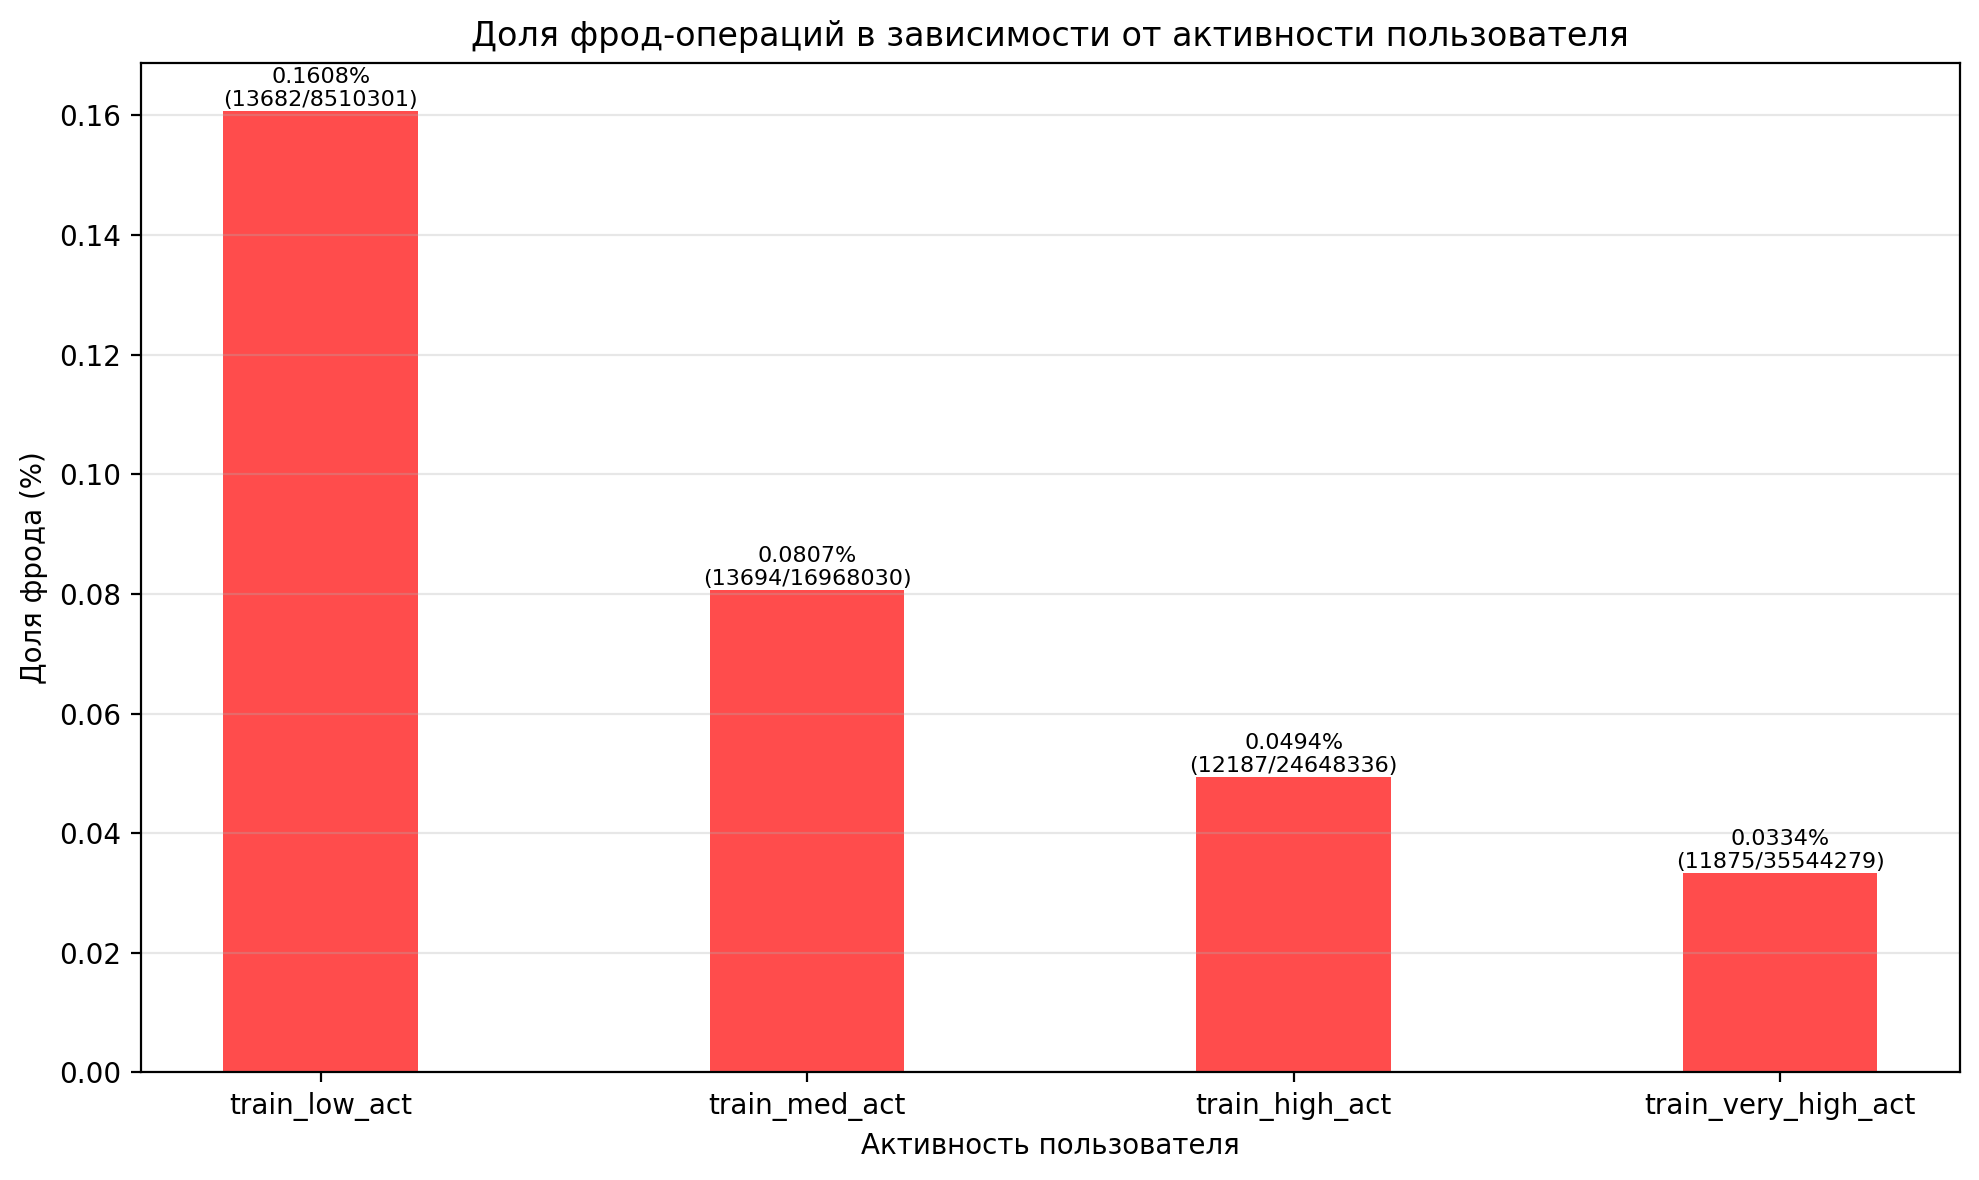

In [20]:
train_all['user_activity_cat'] = pd.cut(
    train_all['customer_id'].map(train_user_activity), 
    bins=bins, labels=labels
)

fraud_by_activity = []
total_by_activity = []

for cat in labels:
    subset = train_all[train_all['user_activity_cat'] == cat]
    fraud_count = (subset['target'] == 1).sum()
    total = len(subset)
    fraud_pct = fraud_count / total * 100
    
    fraud_by_activity.append(fraud_count)
    total_by_activity.append(total)
    
    print(f"{cat}: {fraud_count} фродов из {total} операций ({fraud_pct:.4f}%)")

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(labels))
width = 0.4

bars = ax.bar(x, [f/t*100 for f, t in zip(fraud_by_activity, total_by_activity)], 
              width, color='red', alpha=0.7)

ax.set_xlabel('Активность пользователя')
ax.set_ylabel('Доля фрода (%)')
ax.set_title('Доля фрод-операций в зависимости от активности пользователя')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.grid(True, alpha=0.3, axis='y')

for bar, f, t in zip(bars, fraud_by_activity, total_by_activity):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.0001,
            f'{height:.4f}%\n({f}/{t})', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [21]:
for cat in labels:
    fraud_subset = train_all[(train_all['user_activity_cat'] == cat) & (train_all['target'] == 1)]
    print(f"{cat}: средняя сумма фрода = {fraud_subset['operaton_amt'].mean():.0f}")

train_low_act: средняя сумма фрода = 8749540
train_med_act: средняя сумма фрода = 7995823
train_high_act: средняя сумма фрода = 6340304
train_very_high_act: средняя сумма фрода = 5105857


In [24]:
print(f"{'Категория':<20} {'Среднее':>12} {'Медиана':>12} {'25%':>12} {'75%':>12} {'Макс':>12}")

for cat in labels:
    fraud_subset = train_all[(train_all['user_activity_cat'] == cat) & (train_all['target'] == 1)]
    amt = fraud_subset['operaton_amt']
    print(f"{cat:<20} {amt.mean():>12,.0f} {amt.median():>12,.0f} "
          f"{amt.quantile(0.25):>12,.0f} {amt.quantile(0.75):>12,.0f} {amt.max():>12,.0f}")


=== СТАТИСТИКА СУММ ФРОДА ПО КАТЕГОРИЯМ ===

Категория                 Среднее      Медиана          25%          75%         Макс
--------------------------------------------------------------------------------
train_low_act           8,749,540      994,050       51,534    8,044,758 1,007,112,955
train_med_act           7,995,823      501,426       44,276    5,942,216 1,489,800,763
train_high_act          6,340,304      297,962       39,569    4,000,100  855,700,412
train_very_high_act     5,105,857      149,325       29,789    1,803,374 1,150,380,064


Всего точек для графика: 51438

Распределение по категориям:
category
train_med_act          13694
train_low_act          13682
train_high_act         12187
train_very_high_act    11875
Name: count, dtype: int64


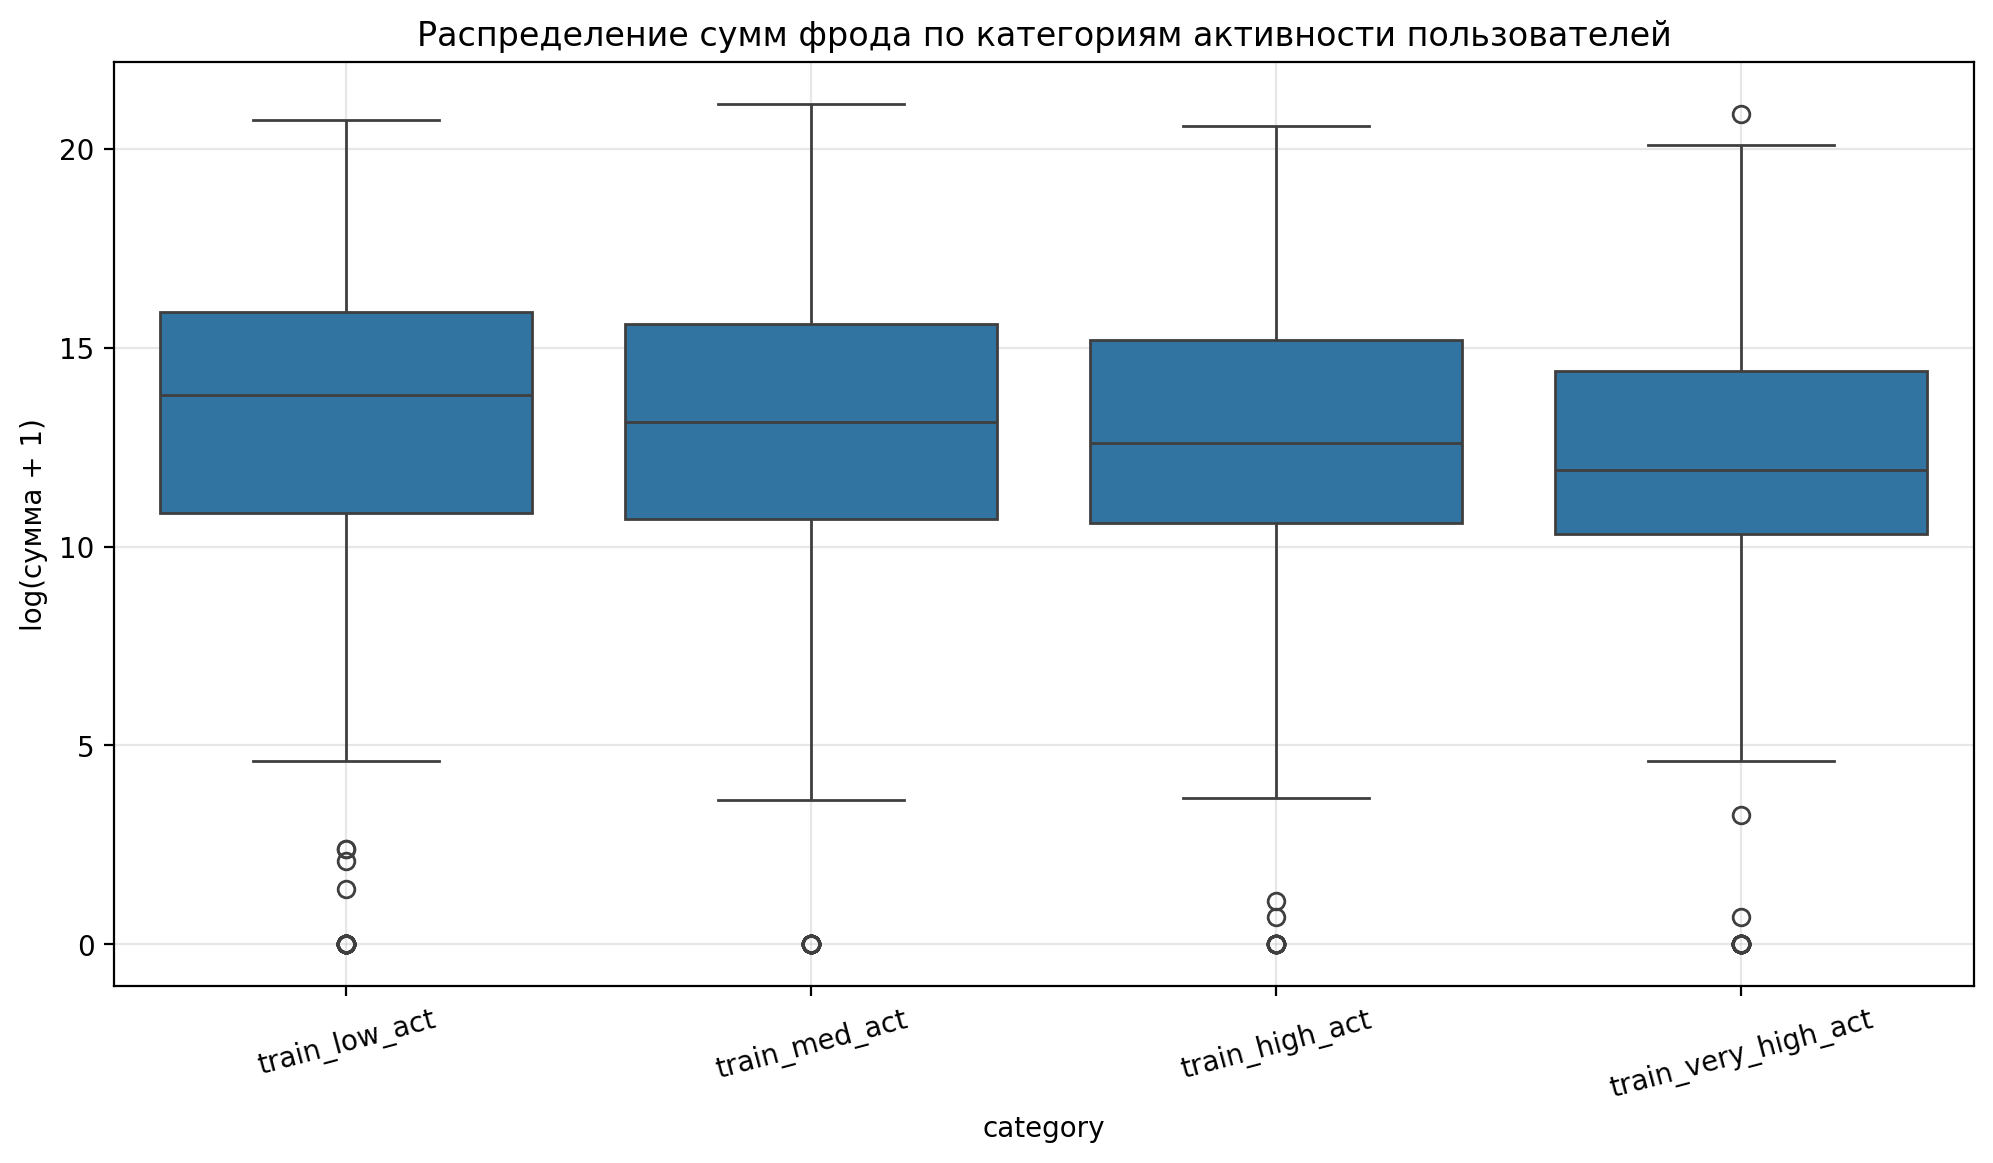

In [30]:

plot_data = []
for cat in labels:
    fraud_subset = train_all[(train_all['user_activity_cat'] == cat) & (train_all['target'] == 1)]
    if len(fraud_subset) > 0:
        temp_df = pd.DataFrame({
            'category': cat,
            'log_amount': np.log1p(fraud_subset['operaton_amt'])
        })
        plot_data.append(temp_df)

plot_df = pd.concat(plot_data, ignore_index=True)

print(f"Всего точек для графика: {len(plot_df)}")
print("\nРаспределение по категориям:")
print(plot_df['category'].value_counts())

# Строим boxplot через seaborn
plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_df, x='category', y='log_amount')
plt.xticks(rotation=15)
plt.ylabel('log(сумма + 1)')
plt.title('Распределение сумм фрода по категориям активности пользователей')
plt.grid(True, alpha=0.3)
plt.show()